In [1]:
%load_ext autoreload
%autoreload 2

In [249]:
from utils.llm_api.client import GPT4AllClient, GPT4AllMessage
import pandas as pd
from utils.pipeline import run_pipeline
from utils.evaluation import evaluate_metrics
import os, io
from utils.pipeline import run_pipeline
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt
import json
from sklearn.cluster import KMeans
import scipy.stats as stats

### Loading map of Europe

In [3]:
## load map from shapefile
world_gdf = gpd.read_file('data/europe/CNTR_RG_20M_2024_3035.shp')
world_gdf = world_gdf.to_crs(epsg=4326)
europe_gdf = world_gdf[world_gdf['EU_STAT'] == 'T']
europe_gdf.loc[78, 'geometry'] = world_gdf[
    world_gdf['CNTR_ID'] == 'FR'
].iloc[0].geometry.geoms[3] ## dropping France's overseas teritories

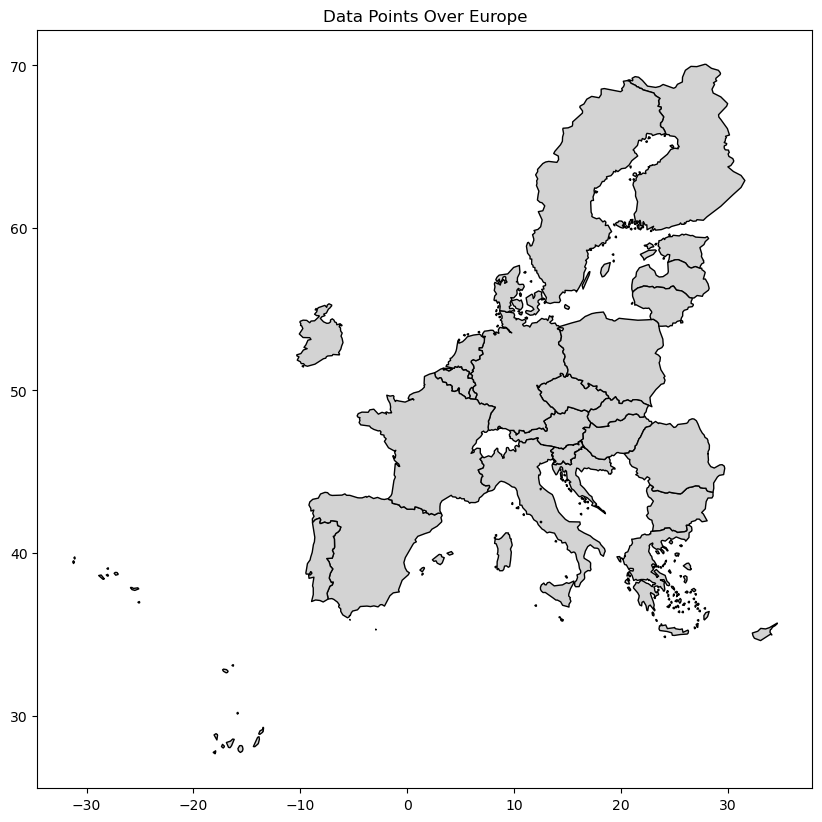

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray') 
plt.title("Data Points Over Europe")
plt.show()

### LLM setup

In [5]:
llm_client = GPT4AllClient()

In [6]:
available_models = llm_client.get_available_models()
available_models

['Reasoner v1',
 'Llama 3.2 3B Instruct',
 'Llama 3.2 1B Instruct',
 'Llama 3.1 8B Instruct 128k',
 'nomic-ai/nomic-embed-text-v1.5-GGUF']

In [7]:
data_gdf = gpd.read_file("data/LUCAS_SOIL_2018_processed.gpkg", crs="EPSG:4326")

In [8]:
with open('./function_headers/all.txt') as f:
    functions = f.readlines()
    functions = "\n".join(functions)

with open('./function_headers/transform.txt') as f:
    transform_functions = f.readlines()
    transform_functions = "\n".join(functions)
    
with open('./function_headers/visualize.txt') as f:
    visualize_functions = f.readlines()
    visualize_functions = "\n".join(functions)

In [46]:
MODEL_NAME_INSTRUCTOR = available_models[0]
MODEL_NAME_CODER = available_models[3]

client_instructor = GPT4AllClient(model_name=MODEL_NAME_INSTRUCTOR)
client_coder = GPT4AllClient(model_name=MODEL_NAME_CODER)

In [21]:
query_types = ['desc', 'geo', 'infer']
BASE_QUERY_DIR = './data/user_query/'
BASE_CORRECT_RESULT_DIR = './data/correct_results/'
BASE_GENERATED_DIR = './data/user_query_generated/'
BASE_METRICS_DIR = './data/metrics/'

model_id = MODEL_NAME_CODER

In [211]:
from utils.llm_api.client import HuggingFaceLLMClient, GPT4AllClient
from utils.llm_api.query import QueryProvider, QueryType
import json
import logging
from typing import Union
import re
import io
import geopandas as gpd
## needed for running solution
import matplotlib.pyplot as plt
import shapely
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy
import sklearn
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from utils.pipeline import (
    extract_json, extract_python_code, clean_python_code, 
    get_description_extraction_function_string, get_solution_function_string
)
from enum import Enum

In [277]:
objective = "Plot on the map all the points with LC0_Desc=Woodland & pH<6 in Europe. Save the result as a png. Use geopandas."

In [278]:
column_descriptions = """
Columns:
- Depth - Depth of the sample. Values: 0_10, 10_20, 20_30. Dtype: object.
- POINTID - Unique identifier of the LUCAS survey point. 8-digit number. Dtype: int64.
- pH_CaCl2 - pH measured in a CaCl2 solution. Range: 2–10. Dtype: float64.
- pH_H2O - pH measured in a soil-water suspension. Range: 2–10. Dtype: float64.
- EC - Electrical conductivity. Unit: mS/m, LOD: 0.1. Dtype: float64.
- OC - Organic carbon content at depth 0-20 cm. Unit: g/kg, LOD: 2. Dtype: float64.
- CaCO3 - Carbonates content at depth 0-20 cm. Unit: g/kg, LOD: 1. Dtype: float64.
- P - Phosphorus content. Unit: mg/kg, LOD: 10. Dtype: float64.
- N - Total nitrogen content. Unit: g/kg, LOD: 0.2. Dtype: float64.
- K - Extractable potassium content. Unit: mg/kg, LOD: 10. Dtype: float64.
- OC (20-30 cm) - Organic carbon content at depth 20-30 cm. Unit: g/kg, LOD: 2. Dtype: float64.
- CaCO3 (20-30 cm) - Carbonates content at depth 20-30 cm. Unit: g/kg, LOD: 1. Dtype: float64.
- Ox_Al - Aluminum oxylate. Unit: mg/kg. Dtype: float64.
- Ox_Fe - Iron oxylate. Unit: mg/kg. Dtype: float64.
- NUTS_0 - NUTS code for the country where the sample was taken. Based on GPS coordinates. Dtype: object.
- NUTS_1 - NUTS 1 code for the location. Derived from survey data. Dtype: object.
- NUTS_2 - NUTS 2 code for the location. Derived from survey data. Dtype: object.
- NUTS_3 - NUTS 3 code for the location. Derived from survey data. Dtype: object.
- TH_LAT - Theoretical latitude. Coordinates in decimal degrees. Dtype: float64.
- TH_LONG - Theoretical longitude. Coordinates in decimal degrees. Dtype: float64.
- SURVEY_DATE - Date of the survey. Dtype: datetime64[ms].
- Elev - Elevation from surveyor GPS. Unit: meters. Dtype: int64.
- LC - LUCAS Land Cover code. Derived from Eurostat. Dtype: object.
- LU - LUCAS Land Use code. Derived from Eurostat. Dtype: object.
- LC0_Desc - Main land cover class description. Derived from Eurostat. Dtype: object.
- LC1_Desc - Detailed land cover class description. Derived from Eurostat. Dtype: object.
- LU1_Desc - Detailed land use class description. Derived from Eurostat. Dtype: object.
- Country - Country of the sample location. Derived from survey data. Dtype: object.
- geometry - Geometry of the sample point. Shapefile data. Dtype: geometry.
"""

In [279]:
buffer = io.StringIO()
data_gdf.info(buf=buffer)
data_description = buffer.getvalue()
buffer = io.StringIO()
europe_gdf.info(buf=buffer)
europe_gdf_description = buffer.getvalue()

In [280]:
type_query = QueryProvider.get_query(QueryType.TYPE, objective=objective)
logging.log(logging.INFO, "Running type query")
type_response = client_instructor.query(type_query)

2025-01-28 23:36:31,722 - Running type query


In [281]:
transform_query = QueryProvider.get_query(QueryType.TRANSFORM, objective=objective, data_description=column_descriptions)
transform_response = client_instructor.query(transform_query)

In [282]:
transform_code = extract_python_code(transform_response)
cleaned_transform_code = clean_python_code(transform_code)
description_extraction_function_code = get_description_extraction_function_string(cleaned_transform_code)
local_scope = {}
exec(description_extraction_function_code, globals(), local_scope)
intermediate_data_description = local_scope['get_transformed_data_description'](data_gdf)

In [283]:
print(cleaned_transform_code)

transformed_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Woodland') & (data_gdf['pH_CaCl2'] < 6)]


In [284]:
if "map" in type_response.lower():
    visualization_query = QueryProvider.get_query(QueryType.VISUALIZE_MAP, objective=objective, intermediate_data_description=intermediate_data_description)
elif "graph" in type_response.lower():
    visualization_query = QueryProvider.get_query(QueryType.VISUALIZE_GRAPH, objective=objective, intermediate_data_description=intermediate_data_description)
elif "print" in type_response.lower():
    visualization_query = QueryProvider.get_query(QueryType.VISUALIZE_PRINT, objective=objective, intermediate_data_description=intermediate_data_description)
visualization_response = client_instructor.query(visualization_query)

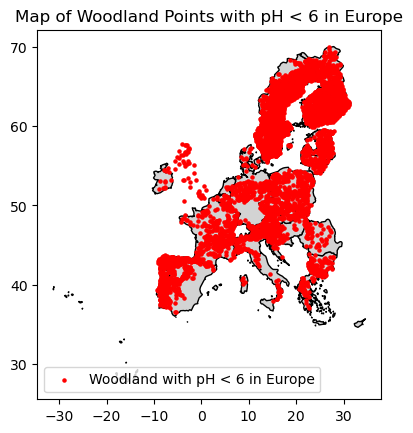

In [285]:
visualize_code = extract_python_code(visualization_response)
cleaned_visualize_code = clean_python_code(visualize_code)
solution_function_string = get_solution_function_string(cleaned_transform_code, cleaned_visualize_code)
local_scope = {}
exec(solution_function_string, globals(), local_scope)
local_scope['solve'](data_gdf, europe_gdf)

In [253]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Calculate the 10th percentile of 'K'
	k_10_percentile = stats.percentileofscore(data_gdf['K'], 90)
	# Filter points where 'K' is in the top 10 percentile
	transformed_gdf = data_gdf[data_gdf['K'] >= k_10_percentile]
	# Assuming europe_gdf is already loaded and contains Europe's map data
	ax = europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	transformed_gdf.plot(markersize=50, ax=ax, column='K', legend=True, cmap='coolwarm')
	plt.title('Map of Points with K in the Top 10 Percentile in Europe')
	plt.savefig('top_10_percentile_k.png')


In [255]:
def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Calculate the 10th percentile of 'K'
	k_10_percentile = stats.percentileofscore(data_gdf['K'], 90)
	# Filter points where 'K' is in the top 10 percentile
	transformed_gdf = data_gdf[data_gdf['K'] >= k_10_percentile]
	# Assuming europe_gdf is already loaded and contains Europe's map data
	europe_gdf.plot(edgecolor='black', color='lightgray')
	transformed_gdf.plot(markersize=5, column='K', legend=True, cmap='coolwarm')
	plt.title('Map of Points with K in the Top 10 Percentile in Europe')
	plt.savefig('top_10_percentile_k.png')

ValueError: aspect must be finite and positive 

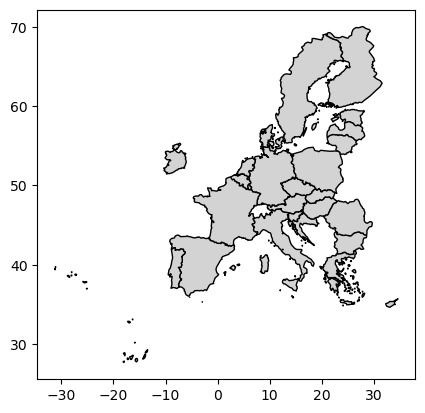

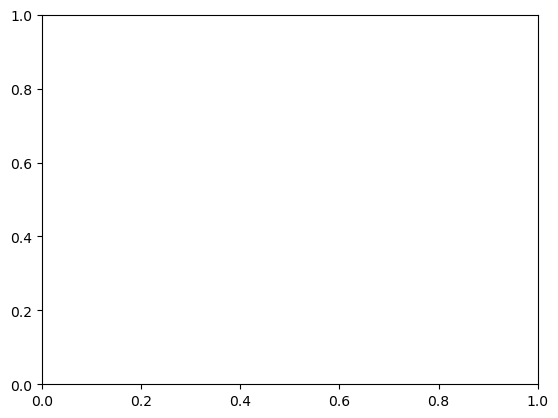

In [256]:
solve(data_gdf, europe_gdf)

2025-01-28 21:34:17,307 - Running initial query
2025-01-28 21:34:24,063 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the 'data_gdf' GeoDataFrame by filtering out points that have pH_CaCl2 <= 6, resulting in a new GeoDataFrame called 'transformed_gdf'.",
  "visualize": "Visualize the transformed data from 'transformed_gdf' as a map of Europe using geopandas. Plot all the remaining points on top of an image of European map and save it as a PNG file."
}
```
2025-01-28 21:34:24,063 - Started parsing response
2025-01-28 21:34:24,064 - Parsing successful
2025-01-28 21:34:24,064 - Running transform query
2025-01-28 21:34:35,189 - Transform query finished successfully, response: 
transformed_data = data_gdf.copy()
transformed_data = transformed_data[transformed_data['pH_CaCl2'] > 6]
2025-01-28 21:34:35,225 - Running visualize query
2025-01-28 21:35:08,569 - Visualize query finished successfully, response: 
import matplotlib.pyplot as plt

# Create a fig

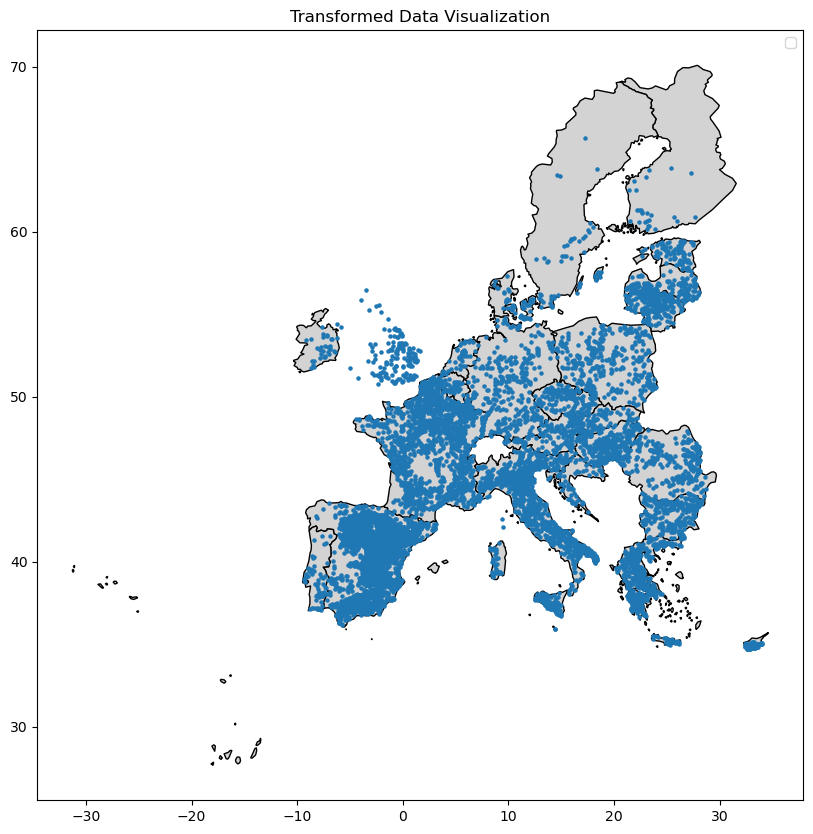

ValueError: Error while running visualize query: no numeric data to plot

<Figure size 640x480 with 0 Axes>

In [30]:
initial_query = QueryProvider.get_query(query_type=QueryType.INITIAL, 
                                        objective=objective, 
                                        data_description=data_description)
logging.log(logging.INFO, "Running initial query")
response = client_instructor.query(initial_query)

logging.log(logging.INFO, f"Initial query finished successfully, response: \n{response}")

logging.log(logging.INFO, "Started parsing response")
try:
    parsed_response = extract_json(response)
    transform_instructions = parsed_response["transform"]
    visualize_instructions = parsed_response["visualize"]
    # intermediate_data_description = parsed_response["column_definitions"]
except Exception as e:
    raise ValueError("Parsed response is not in json format or does not contain transform, visualize, or column_definitions keys.")
logging.log(logging.INFO, "Parsing successful")

logging.log(logging.INFO, "Running transform query")
transform_query = QueryProvider.get_query(query_type=QueryType.TRANSFORM,
                                        objective=transform_instructions,
                                        data_description=data_description,
                                        functions=transform_functions,)
transform_response = client_coder.query(transform_query)

logging.log(logging.INFO, f"Transform query finished successfully, response: \n{extract_python_code(transform_response)}")

try:
    transform_code = extract_python_code(transform_response)
    cleaned_transform_code = clean_python_code(transform_code)
    description_extraction_function_code = get_description_extraction_function_string(cleaned_transform_code)
    local_scope = {}
    exec(description_extraction_function_code, globals(), local_scope)
    intermediate_data_description = local_scope['get_transformed_data_description'](data_gdf)
except Exception as e:
    raise ValueError(f"Error while running transform query: {e}")

logging.log(logging.INFO, "Running visualize query")

visualize_query = QueryProvider.get_query(query_type=QueryType.VISUALIZE,
                                            objective=visualize_instructions,
                                            europe_gdf_description=europe_gdf_description,
                                            intermediate_data_description=intermediate_data_description,
                                            functions=visualize_functions
                                            )

visualize_response = client_coder.query(visualize_query)
logging.log(logging.INFO, f"Visualize query finished successfully, response: \n{extract_python_code(visualize_response)}")

try:
    visualize_code = extract_python_code(visualize_response)
    cleaned_visualize_code = clean_python_code(visualize_code)
    solution_function_string = get_solution_function_string(cleaned_transform_code, cleaned_visualize_code)
    local_scope = {}
    exec(solution_function_string, globals(), local_scope)
    local_scope['solve'](data_gdf, europe_gdf)
except Exception as e:
    raise ValueError(f"Error while running visualize query: {e}")

In [27]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	transformed_data = data_gdf.copy()  
	transformed_data = transformed_data[transformed_data['pH_CaCl2'] > 6]
	fig, ax = plt.subplots(figsize=(10, 10))
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	transformed_data.plot(ax=ax, markersize=5, column=None)
	ax.set_title('Transformed LUCAS-SOIL-2018 Data in Europe')
	ax.set_xlabel('Longitude')
	ax.set_ylabel('Latitude')
	plt.savefig("transformed_data_in_europe.png")
	plt.show()


2025-01-21 22:09:16,221 - Running initial query


Processing 10 desc queries


2025-01-21 22:09:27,717 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the 'data_gdf' GeoDataFrame by filtering for unique land types and selecting the one with the highest pH_H2O. This can be done by grouping the data by LC0_Desc, aggregating on max(pH_H2O), and then sorting in descending order to find the land type with the maximum pH value.",
  "visualize": "Visualize the transformed GeoDataFrame 'transformed_gdf' by overlaying a map of Europe with points representing the unique land types from the dataset. Use different colors or markers for each land type, and include a legend to distinguish between them. A pie chart can also be added showing the distribution of pH_H2O values among the three top land types."
}
```
2025-01-21 22:09:27,717 - Started parsing response
2025-01-21 22:09:27,717 - Parsing successful
2025-01-21 22:09:27,717 - Running transform query
2025-01-21 22:09:38,830 - Transform query finished successfully, response: 
transforme

Error: Error while running transform query: "None of [Index(['Artificial land', 'Bareland', 'Cropland', 'Grassland', 'Shrubland',\n       'Water', 'Wetlands', 'Woodland'],\n      dtype='object')] are in the [index]"


2025-01-21 22:09:44,919 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the data by filtering for rows where 'pH_H2O' is not null, creating a new GeoDataFrame called 'filtered_gdf', then groupby 'LC0_Desc', and find the highest 'pH_H2O' value. The result will be stored in the column '_max_pH_H2O'.",
  "visualize": "Visualize the land types (LC0_Desc) with the maximum pH_H2O values by overlaying them on a map of Europe using a choropleth map, where each LC0_Desc is colored according to its corresponding max_pH_H2O value"
}
```
2025-01-21 22:09:44,921 - Started parsing response
2025-01-21 22:09:44,921 - Parsing successful
2025-01-21 22:09:44,921 - Running transform query
2025-01-21 22:09:55,457 - Transform query finished successfully, response: 
transformed_data = data_gdf[data_gdf['pH_H2O'].notnull()].copy()  # Filter for rows where 'pH_H2O' is not null

# Groupby 'LC0_Desc', find the highest 'pH_H2O' value and store it in '_max_pH_H2O'
transformed_

...

2025-01-21 22:10:27,918 - Initial query finished successfully, response: 
```json
{
  "transform": "First, we group the data by 'LC0_Desc' and sum up the values in column 'K'. This can be done using the pandas DataFrame's groupby() function. The result is stored in a new GeoDataFrame called 'transformed_gdf'.",
  "visualize": "Then, we plot the sum of 'K' for each unique value in the 'LC0_Desc' column by plotting bar charts or histograms directly from transformed data using matplotlib and geopandas to visualize these values on an overlay map of Europe. This will help us understand which land cover types are associated with higher potassium levels."
}
```
2025-01-21 22:10:27,919 - Started parsing response
2025-01-21 22:10:27,919 - Parsing successful
2025-01-21 22:10:27,920 - Running transform query
2025-01-21 22:10:37,764 - Transform query finished successfully, response: 
transformed_data = data_gdf.copy()

# Group the data by 'LC0_Desc' and sum up the values in column 'K'
transformed_

Error: Error while running visualize query: Axes.scatter() got multiple values for argument 'x'


2025-01-21 22:11:02,175 - Initial query finished successfully, response: 
```json
{
  "transform": "The transform part of the objective involves creating a new GeoDataFrame 'transformed_gdf' from 'data_gdf'. This is done by selecting only the columns needed for further analysis, which are 'K' and 'LC0_Desc'. Then, groupby 'LC0_Desc' on 'transfomed_gdf', summing up 'K' values and storing these results in a new GeoDataFrame. The resulting transformed data will be stored as a geographic object with unique land cover descriptions from the LUCAS-SOIL-2018 dataset.",
  "visualize": "The visualize part of the objective involves printing out the sum of 'K' for each unique value in the 'LC0_Desc' column, which means displaying aggregated values grouped by different types of land covers. This can be achieved through a bar chart or other visualization tools."
}
```
2025-01-21 22:11:02,176 - Started parsing response
2025-01-21 22:11:02,176 - Parsing successful
2025-01-21 22:11:02,177 - Running tra

Error: Error while running transform query: name 'geopandas' is not defined


2025-01-21 22:11:24,402 - Initial query finished successfully, response: 
```json
{
  "transform": "The 'transform' part of the objective involves grouping the data by unique values in the 'LC0_Desc' column and summing up the corresponding 'K' values. This operation will result in a new GeoDataFrame called 'transformed_gdf', where each row represents a unique value in 'LC0_Desc' with its associated total 'K'.",
  "visualize": "The 'visualize' part of the objective includes printing the sum of 'K' for each unique value in the 'LC0_Desc' column. This will involve using the groupby function on 'data_gdf', taking a mean (since we're only interested in numerical columns and thus can ignore non-numeric) after specifying LC0_Desc as the grouping variable, then printing out the result."
}
```
2025-01-21 22:11:24,403 - Started parsing response
2025-01-21 22:11:24,403 - Parsing successful
2025-01-21 22:11:24,404 - Running transform query
2025-01-21 22:11:34,259 - Transform query finished success

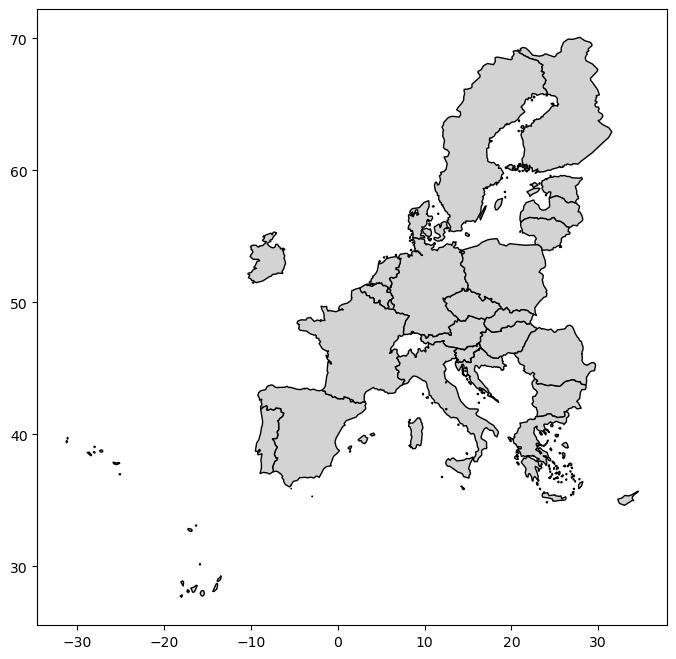

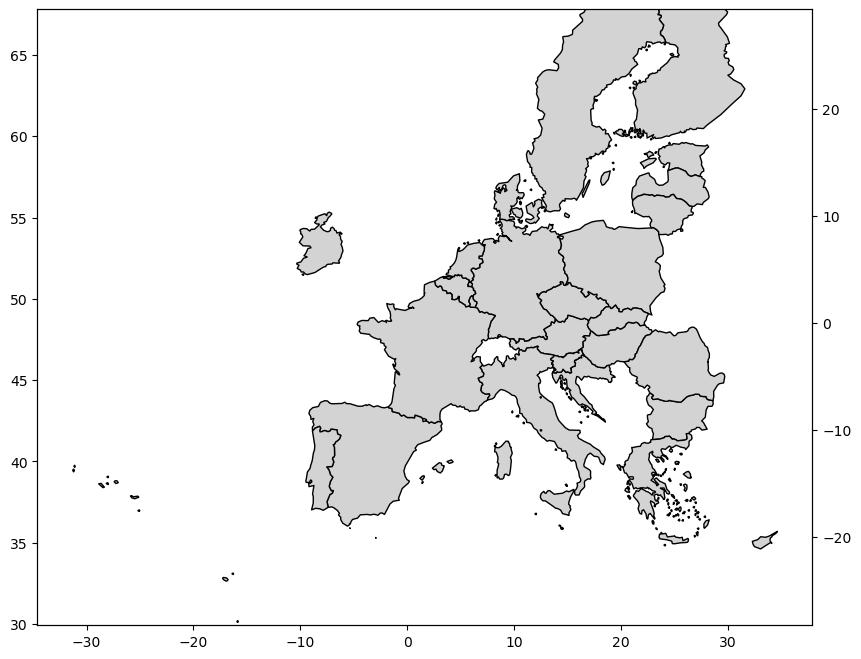

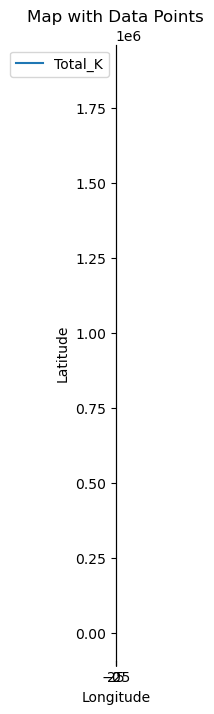

2025-01-21 22:11:53,927 - Using default tokenizer.
2025-01-21 22:11:53,947 - Running initial query
2025-01-21 22:11:59,352 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the data by grouping 'data_gdf' GeoDataFrame based on the 'LC0_Desc' column, then calculate and assign the average 'OC' value for each group to a new column called 'avg_OC'. The resulting transformed data is stored in the 'transformed_gdf' GeoDataFrame.",
  "visualize": "Visualize the average 'OC' values by land type ('LC0_Desc') as bar chart. Save the plot as a png image file."
}
```
2025-01-21 22:11:59,353 - Started parsing response
2025-01-21 22:11:59,353 - Parsing successful
2025-01-21 22:11:59,353 - Running transform query
2025-01-21 22:12:11,724 - Transform query finished successfully, response: 
import pandas as pd

# Group the data by 'LC0_Desc' column and calculate average 'OC' value for each group
transformed_data = data_gdf.groupby('LC0_Desc')['OC'].mean().reset_index()

Error: Error while running visualize query: name 'quote' is not defined


2025-01-21 22:12:32,777 - Initial query finished successfully, response: 
```json
{
  "transform": "The 'OC' column is grouped by the unique values in LC0_Desc and its average value for each land type is calculated. This results in a new GeoDataFrame called 'transformed_gdf'.",
  "visualize": "A bar plot of the averaged OC for each land type (LC0_Desc) from the transformed data stored in 'transformed_gdf' is created, saved as a .png file."
}
```
2025-01-21 22:12:32,778 - Started parsing response
2025-01-21 22:12:32,779 - Parsing successful
2025-01-21 22:12:32,779 - Running transform query
2025-01-21 22:12:43,341 - Transform query finished successfully, response: 
transformed_data = data_gdf.groupby('LC0_Desc')['OC'].mean().reset_index()
transformed_data.columns = ['land_type', 'average_OC']
transformed_data['geometry'] = None

# Keep only the geometry column from original dataframe for transformed dataframe
for index, row in transformed_data.iterrows():
    transformed_data.loc[index, 

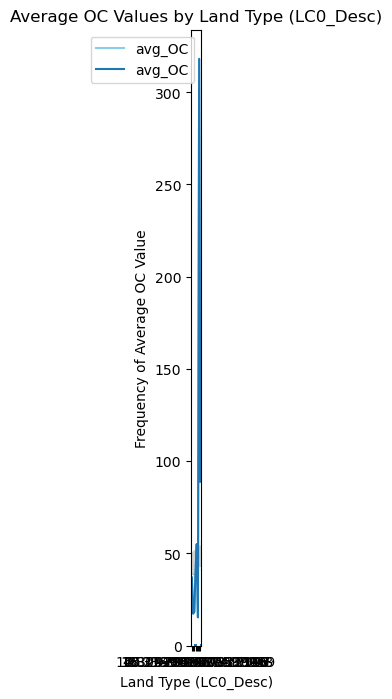

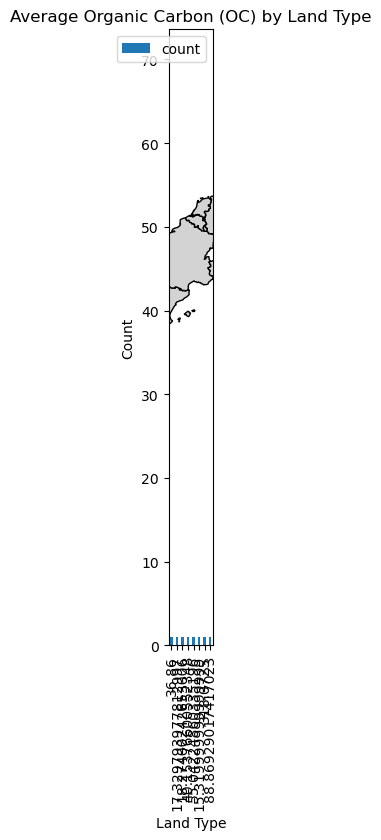

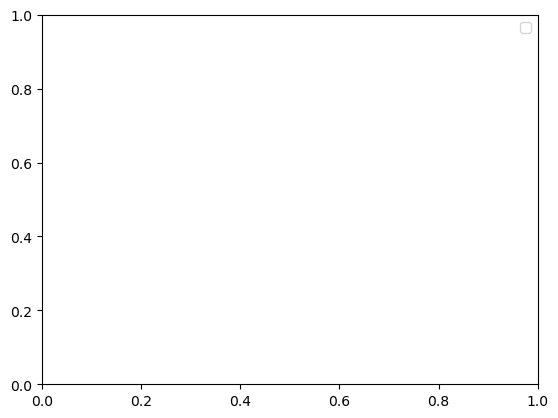

2025-01-21 22:12:57,508 - Using default tokenizer.
2025-01-21 22:12:57,531 - Running initial query
2025-01-21 22:13:03,830 - Initial query finished successfully, response: 
```json
{
  "transform": {
    "Filter the GeoDataFrame for south Europe by NUTS_0 column and keep only rows where it's equal to 'ES' (Spain). Then, groupby EU region and calculate mean of pH_H2O. The result will be stored in a new GeoDataFrame called 'south_eu_ph_gdf'."
  },
  "visualize": {
    "Use the transformed data from south_eu_ph_gdf and plot a bar chart with NUTS_1 as x-axis (EU region) and pH_H2O mean on y-axis. For better clarity, you may want to sort the bars by value in descending order."
  }
}
```
2025-01-21 22:13:03,830 - Started parsing response
2025-01-21 22:13:03,846 - Running initial query


Error: Parsed response is not in json format or does not contain transform, visualize, or column_definitions keys.


2025-01-21 22:13:09,661 - Initial query finished successfully, response: 
```json
{
  "transform": "First, filter the 'data_gdf' GeoDataFrame to include only data from south EU by selecting rows where NUTS_1 is in a specific list of regions. Then, calculate the average pH for each region using the groupby function on column 'pH_H2O'. The result will be stored in a new GeoDataFrame called 'transformed_gdf' with the calculated averages and geometry.",
  "visualize": "Overlay the transformed data from 'transformed_gdf' onto an empty map of Europe. Then, plot bar charts for each region showing their average pH values along with error bars representing standard deviation."
}
```
2025-01-21 22:13:09,662 - Started parsing response
2025-01-21 22:13:09,662 - Parsing successful
2025-01-21 22:13:09,663 - Running transform query
2025-01-21 22:13:21,113 - Transform query finished successfully, response: 
transformed_data = data_gdf[(data_gdf['NUTS_1'].isin(['EL', 'ES', 'PT']))].groupby('NUTS_2').ag

Error: Error while running visualize query: float() argument must be a string or a real number, not 'NoneType'


2025-01-21 22:13:45,835 - Initial query finished successfully, response: 
```json
{
  "transform": "To solve the first objective, we will create a new GeoDataFrame 'south_eu_gdf' that includes only the rows from 'data_gdf' where NUTS_1 is in ['ES', 'IT', 'FR']. We will then calculate the average pH for this subset of data by taking the mean of the 'pH_H2O' column, which contains the hydrogen ion concentration. This operation results in a new GeoDataFrame called 'transformed_gdf'.",
  "visualize": "To visualize the result, we will use folium to create an interactive map of Europe and overlay the average pH values onto it for each NUTS_1 region ('ES', 'IT', 'FR'). We will also add some visual cues such as markers and/or popup information with the calculated average pH value. This visualization will allow users to explore how soil properties vary across different regions."
}
```
2025-01-21 22:13:45,836 - Started parsing response
2025-01-21 22:13:45,837 - Parsing successful
2025-01-21 22:1

...

2025-01-21 22:19:18,681 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the 'data_gdf' GeoDataFrame by selecting only the columns of interest ('K') and then using a kernel density estimation (KDE) to transform it. The transformed data will be stored in 'transformed_gdf'.",
  "visualize": "Visualize the distribution of the K values from the 'transformed_gdf' GeoDataFrame with a KDE overlay. Save this visualization as a PNG image."
}
```
2025-01-21 22:19:18,682 - Started parsing response
2025-01-21 22:19:18,682 - Parsing successful
2025-01-21 22:19:18,683 - Running transform query
2025-01-21 22:19:30,296 - Transform query finished successfully, response: 
# Select the column of interest 'K'
transformed_data = data_gdf[['geometry', 'K']]

# Perform kernel density estimation (KDE) on the selected column 'K' and store it in a new column called 'kde_k'
from scipy.stats import gaussian_kde
import numpy as np

def kdeplot(x, y):
    x_values = np.linspace(

Error: Error while running transform query: 'float' object has no attribute 'min'


2025-01-21 22:19:35,018 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the 'data_gdf' GeoDataFrame to create a new dataframe called 'k_values_df'. This transformation involves selecting only the column named 'K' from 'data_gdf', convert it into numeric representation and standardize its scale. The resulting transformed data is stored in 'transformed_gdf'",
  "visualize": "Use matplotlib library to plot the histogram of K values with a kernel density estimate (KDE) overlay, then save this figure as an image file called k_kde.png"
}
```
2025-01-21 22:19:35,018 - Started parsing response
2025-01-21 22:19:35,019 - Parsing successful
2025-01-21 22:19:35,019 - Running transform query
2025-01-21 22:19:44,005 - Transform query finished successfully, response: 
# Select the 'K' column from data_gdf and convert it to numeric representation
transformed_data = data_gdf[['geometry', 'K']].copy()

# Standardize the scale of K values
from sklearn.preprocessing i

Error: Error while running transform query: name 'pd' is not defined


2025-01-21 22:20:19,333 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the data by filtering rows where 'EC' is greater than 10 and then calculate the average of column 'K'. The resulting transformed GeoDataFrame will be stored in a new variable called 'transformed_gdf'. This involves creating an intermediate step to first filter the original data, which results in filtered_data, before calculating the mean value.",
  
  "visualize": "Visualize the calculated average by plotting it as a heatmap or choropleth map over Europe. We can use matplotlib and/or folium libraries for this purpose."
}
```
2025-01-21 22:20:19,333 - Started parsing response
2025-01-21 22:20:19,334 - Parsing successful
2025-01-21 22:20:19,334 - Running transform query
2025-01-21 22:20:28,920 - Transform query finished successfully, response: 
# Filter rows where 'EC' is greater than 10 and store the result in filtered_data
filtered_data = data_gdf[data_gdf['EC'] > 10]

# Calcul

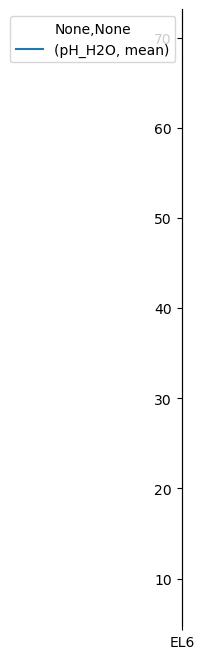

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x700 with 0 Axes>

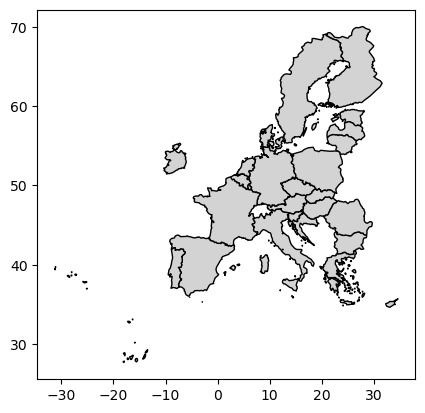

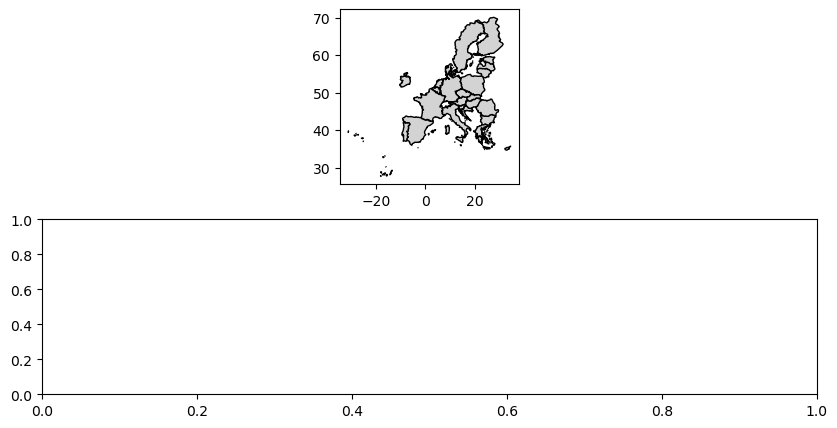

<Figure size 1000x800 with 0 Axes>

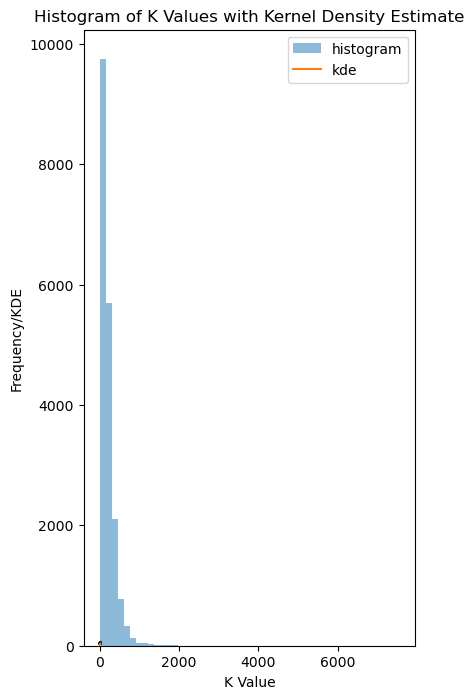

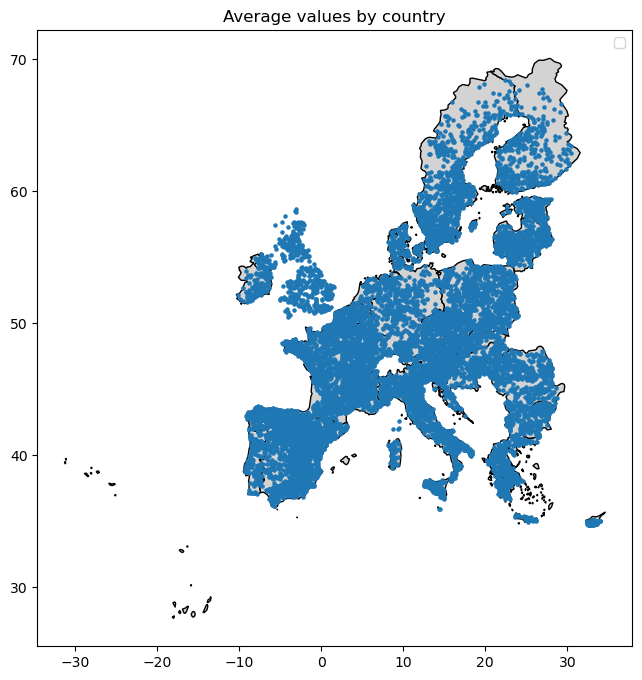

2025-01-21 22:20:45,132 - Using default tokenizer.
2025-01-21 22:20:45,152 - Running initial query


Processing 10 geo queries


2025-01-21 22:20:49,517 - Initial query finished successfully, response: 
```json
{
  "transform": "Filter the LUCAS-SOIL-2018 dataset to keep only rows where pH_CaCl2 > 6 and create a new GeoDataFrame called 'transformed_gdf' with these transformed data.",
  "visualize": "Plot all the points that have pH_CaCl2 > 6 on top of an empty map of Europe using geopandas. Save the resulting image as a png file."
}
```
2025-01-21 22:20:49,517 - Started parsing response
2025-01-21 22:20:49,517 - Parsing successful
2025-01-21 22:20:49,518 - Running transform query
2025-01-21 22:20:57,437 - Transform query finished successfully, response: 
transformed_data = data_gdf[(data_gdf['pH_CaCl2'] > 6)].copy()
2025-01-21 22:20:57,449 - Running visualize query
2025-01-21 22:21:10,546 - Visualize query finished successfully, response: 
import matplotlib.pyplot as plt

# Set the figure size to 10x8 inches and a DPI of 100
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

# Plot europe_gdf as base map with bla

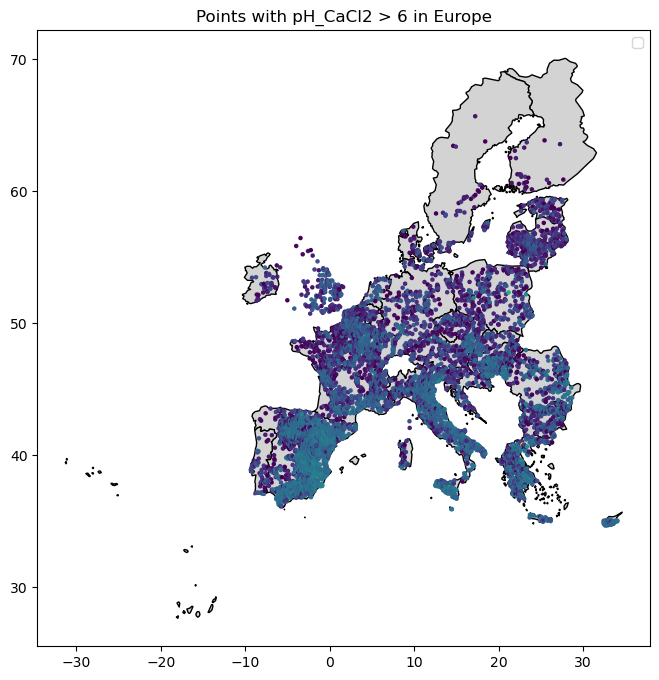

2025-01-21 22:21:11,122 - Using default tokenizer.
2025-01-21 22:21:11,142 - Running initial query
2025-01-21 22:21:16,292 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the data by filtering 'data_gdf' to keep only rows where LC0_Desc is either 'Grassland' or 'Woodland', and OC is greater than 20. Select specific columns (LC0_Desc, OC) from this transformed dataset into a new GeoDataFrame called 'transformed_gdf'",
  "visualize": "Visualize the transformed data by plotting all points in 'transformed_gdf' on a map of Europe using geopandas and save it as a png image. Set the title of the plot to \"Grassland and Woodland with OC > 20\""
}
```
2025-01-21 22:21:16,292 - Started parsing response
2025-01-21 22:21:16,294 - Parsing successful
2025-01-21 22:21:16,294 - Running transform query
2025-01-21 22:21:24,241 - Transform query finished successfully, response: 
transformed_data = data_gdf.loc[(data_gdf['LC0_Desc'].isin(['Grassland', 'Woodland'])) & 

Error: Error while running visualize query: 'GeoDataFrame' object has no attribute 'geom'


2025-01-21 22:21:41,316 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the data by filtering for points where LC0_Desc is either 'Grassland' or 'Woodland', and OC is greater than 20. The resulting GeoDataFrame will be stored in a variable called 'transformed_gdf'.",
  "visualize": "Visualize the transformed data by plotting all the points on a map of Europe, saving it as a png file."
}
```
2025-01-21 22:21:41,316 - Started parsing response
2025-01-21 22:21:41,316 - Parsing successful
2025-01-21 22:21:41,318 - Running transform query
2025-01-21 22:21:50,579 - Transform query finished successfully, response: 
import geopandas as gpd

# Load the Europe map into a GeoDataFrame called 'europe_gdf'
europe_gdf = gpd.read_file('path/to/europe_map.shp')

transformed_data = data_gdf[(data_gdf['LC0_Desc'].isin(['Grassland', 'Woodland'])) & (data_gdf['OC'] > 20)].copy()

# Keep the geometry column
transformed_data[['geometry']] = transformed_data[["geometry"]

Error: Error while running transform query: Failed to open dataset (flags=68): path/to/europe_map.shp


2025-01-21 22:21:55,405 - Initial query finished successfully, response: 
```json
{
  "transform": "Filter the 'data_gdf' GeoDataFrame to include only rows where LC0_Desc is either 'Grassland' or 'Woodland', and then filter those points where OC (organic carbon) content is greater than 20. The resulting transformed data will be stored in a new GeoDataFrame called 'transformed_gdf'.",
  "visualize": "Plot the filtered points from the 'transformed_gdf' on an interactive map of Europe using geopandas, and save the map as a png file."
}
```
2025-01-21 22:21:55,405 - Started parsing response
2025-01-21 22:21:55,405 - Parsing successful
2025-01-21 22:21:55,406 - Running transform query
2025-01-21 22:22:04,518 - Transform query finished successfully, response: 
transformed_data = data_gdf[(data_gdf['LC0_Desc'].isin(['Grassland', 'Woodland'])) & (data_gdf['OC'] > 20)]
2025-01-21 22:22:04,528 - Running visualize query
2025-01-21 22:22:15,370 - Visualize query finished successfully, response: 
i

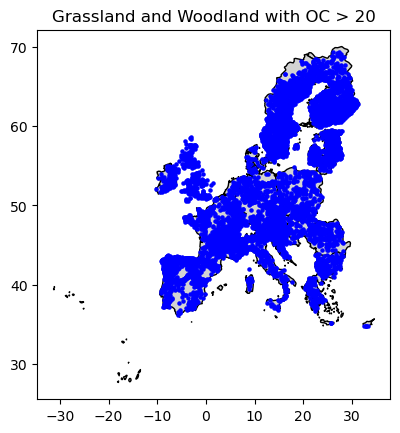

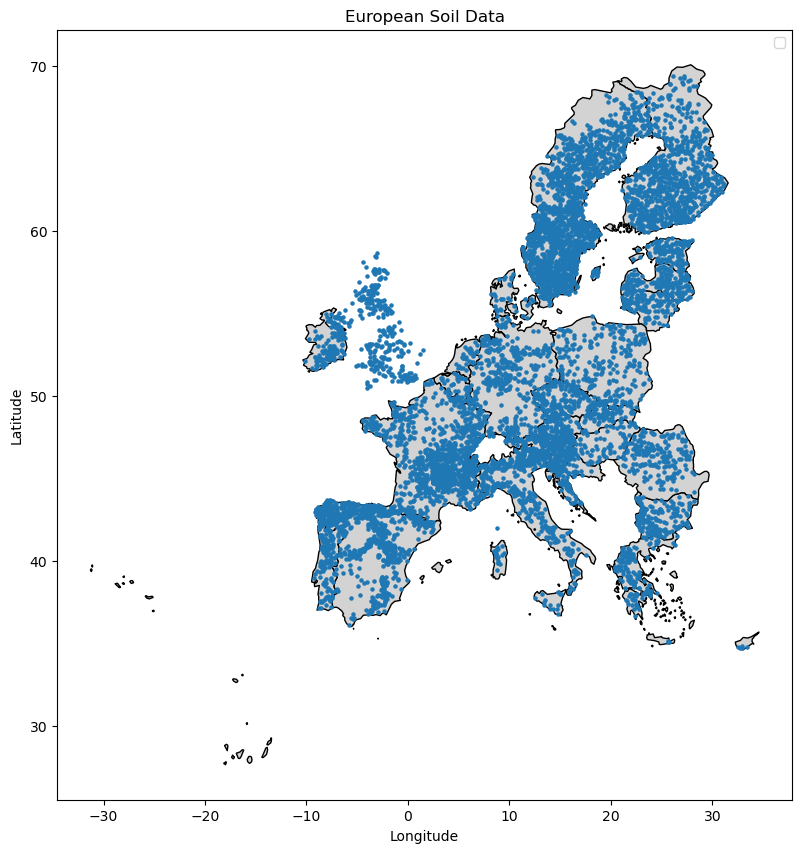

2025-01-21 22:22:16,010 - Using default tokenizer.
2025-01-21 22:22:16,029 - Running initial query
2025-01-21 22:22:21,135 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the 'data_gdf' GeoDataFrame to filter points with LC0_Desc=Woodland. This will involve selecting only rows where the value in column 'LC0_Desc' is equal to 'Woodland'. The resulting transformed data should be stored in a new GeoDataFrame called 'transformed_gdf'.",
  "visualize": "Visualize all the points from 'transformed_gdf' by plotting them on a map of Europe. This will involve using geopandas and matplotlib libraries to create an interactive or static map, where each point corresponds to a Woodland in Europe."
}
```
2025-01-21 22:22:21,135 - Started parsing response
2025-01-21 22:22:21,136 - Parsing successful
2025-01-21 22:22:21,136 - Running transform query
2025-01-21 22:22:32,588 - Transform query finished successfully, response: 
# Import necessary libraries (assuming the

Error: Error while running transform query: name 'geopandas' is not defined


2025-01-21 22:22:36,568 - Initial query finished successfully, response: 
```json
{
  "transform": "Filter the data to include only rows where LC0_Desc is Woodland, then create a new GeoDataFrame 'transformed_gdf' with these filtered results.",
  "visualize": "Plot all points in transformed_gdf using geopandas. Save the result as an image file named 'woodland_points.png'."
}
```
2025-01-21 22:22:36,568 - Started parsing response
2025-01-21 22:22:36,569 - Parsing successful
2025-01-21 22:22:36,569 - Running transform query
2025-01-21 22:22:45,220 - Transform query finished successfully, response: 
transformed_data = data_gdf.loc[data_gdf['LC0_Desc'] == 'Woodland']
2025-01-21 22:22:45,232 - Running visualize query
2025-01-21 22:22:56,553 - Visualize query finished successfully, response: 
import matplotlib.pyplot as plt

# Set the figure size
fig, ax = plt.subplots(figsize=(10, 10))

# Plot europe_gdf as base map with borders and light gray color for countries
europe_gdf.plot(ax=ax, edge

Error: Error while running visualize query: aspect must be finite and positive 


2025-01-21 22:23:02,081 - Initial query finished successfully, response: 
```json
{
  "transform": "Select rows from 'data_gdf' GeoDataFrame where LC0_Desc equals Woodland and save the result as a new GeoDataFrame called 'woodland_points'. The transformed data will contain all columns of original dataset, but only points with Land Cover type Woodland are kept.",
  "visualize": "Plot all points in 'woodland_points' on top of a map of Europe. Use geopandas and save the result as an image file (e.g., .png). The plot should display geographical distribution of woodland areas across Europe."
}
```
2025-01-21 22:23:02,081 - Started parsing response
2025-01-21 22:23:02,084 - Parsing successful
2025-01-21 22:23:02,085 - Running transform query
2025-01-21 22:23:10,733 - Transform query finished successfully, response: 
transformed_data = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']
2025-01-21 22:23:10,747 - Running visualize query
2025-01-21 22:23:21,717 - Visualize query finished successfully,

...

2025-01-21 22:25:03,661 - Initial query finished successfully, response: 
{
"transform": "First, filter the data to only include rows where 'K' is above its median value. Then, create a new column 'k_above_median' and assign 1 if 'K' is greater than its median value, otherwise assign 0.",
"visualize": "Create a scatter plot map of Europe using geopandas with markers for locations where 'k_above_median == 1', saving the result as a png file. Use crs=epsg:3035 to ensure correct spatial referencing."
}
2025-01-21 22:25:03,661 - Started parsing response
2025-01-21 22:25:03,673 - Running initial query


Error: Parsed response is not in json format or does not contain transform, visualize, or column_definitions keys.


2025-01-21 22:25:09,062 - Initial query finished successfully, response: 
```
{
  "transform": {
    "Select columns of interest: Select the geometry column and a column named 'K' from data_gdf, as we are only interested in its values. Then calculate the median value of these K values.
Filter out locations where K is above or equal to this median by using boolean indexing with np.greater_equal (or >=) operator on the filtered result.",
  },
  
  "visualize": {
    "Map creation: Create a map with markers for all locations where 'K' is greater than its calculated median value. This can be done by passing the transformed data to GeoDataFrame.explore method, selecting the geometry column as CRS and then using .plot.scatter() function. Save this map in png format."
  }
}
```
2025-01-21 22:25:09,062 - Started parsing response
2025-01-21 22:25:09,077 - Running initial query


Error: Parsed response is not in json format or does not contain transform, visualize, or column_definitions keys.


2025-01-21 22:25:13,189 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the data by creating a new column 'K_above_median' that is True if the value of K is above its median, and False otherwise. Filter the GeoDataFrame to only include rows where 'K_above_median' is True.",
  
  "visualize": "Visualize the filtered GeoDataFrame as a map with markers at each location using geopandas. Save the result as an image file in PNG format."
}
```
2025-01-21 22:25:13,190 - Started parsing response
2025-01-21 22:25:13,191 - Parsing successful
2025-01-21 22:25:13,192 - Running transform query
2025-01-21 22:25:22,871 - Transform query finished successfully, response: 
# Calculate the median of K values and create a new column 'K_above_median'
transformed_data = data_gdf.copy()
median_K = transformed_data['K'].median()

transformed_data['K_above_median'] = transformed_data.apply(lambda row: True if row['K'] > median_K else False, axis=1)

# Filter the GeoDataFram

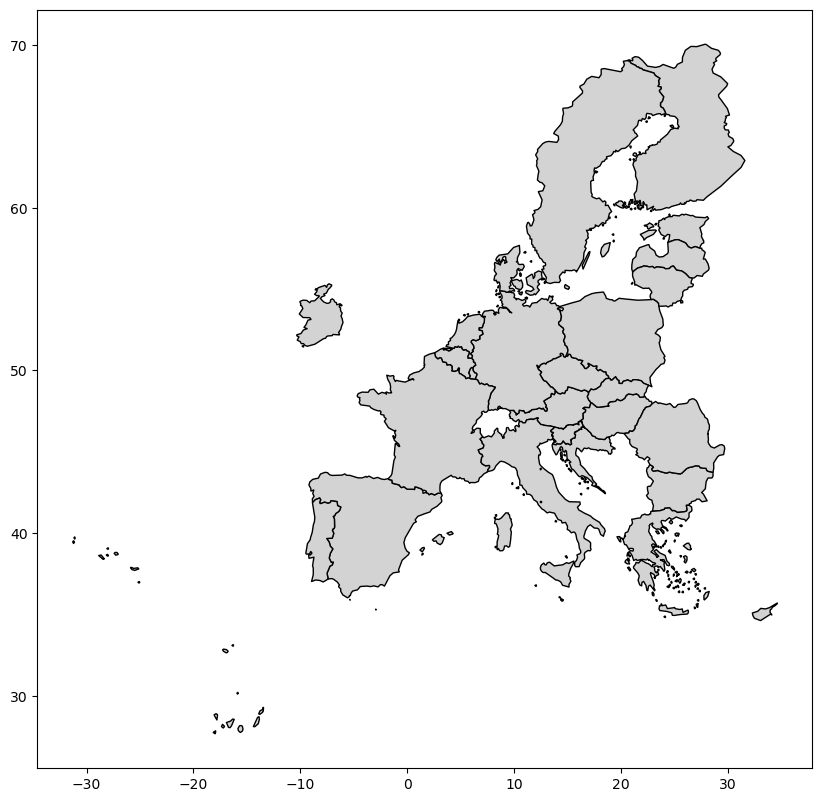

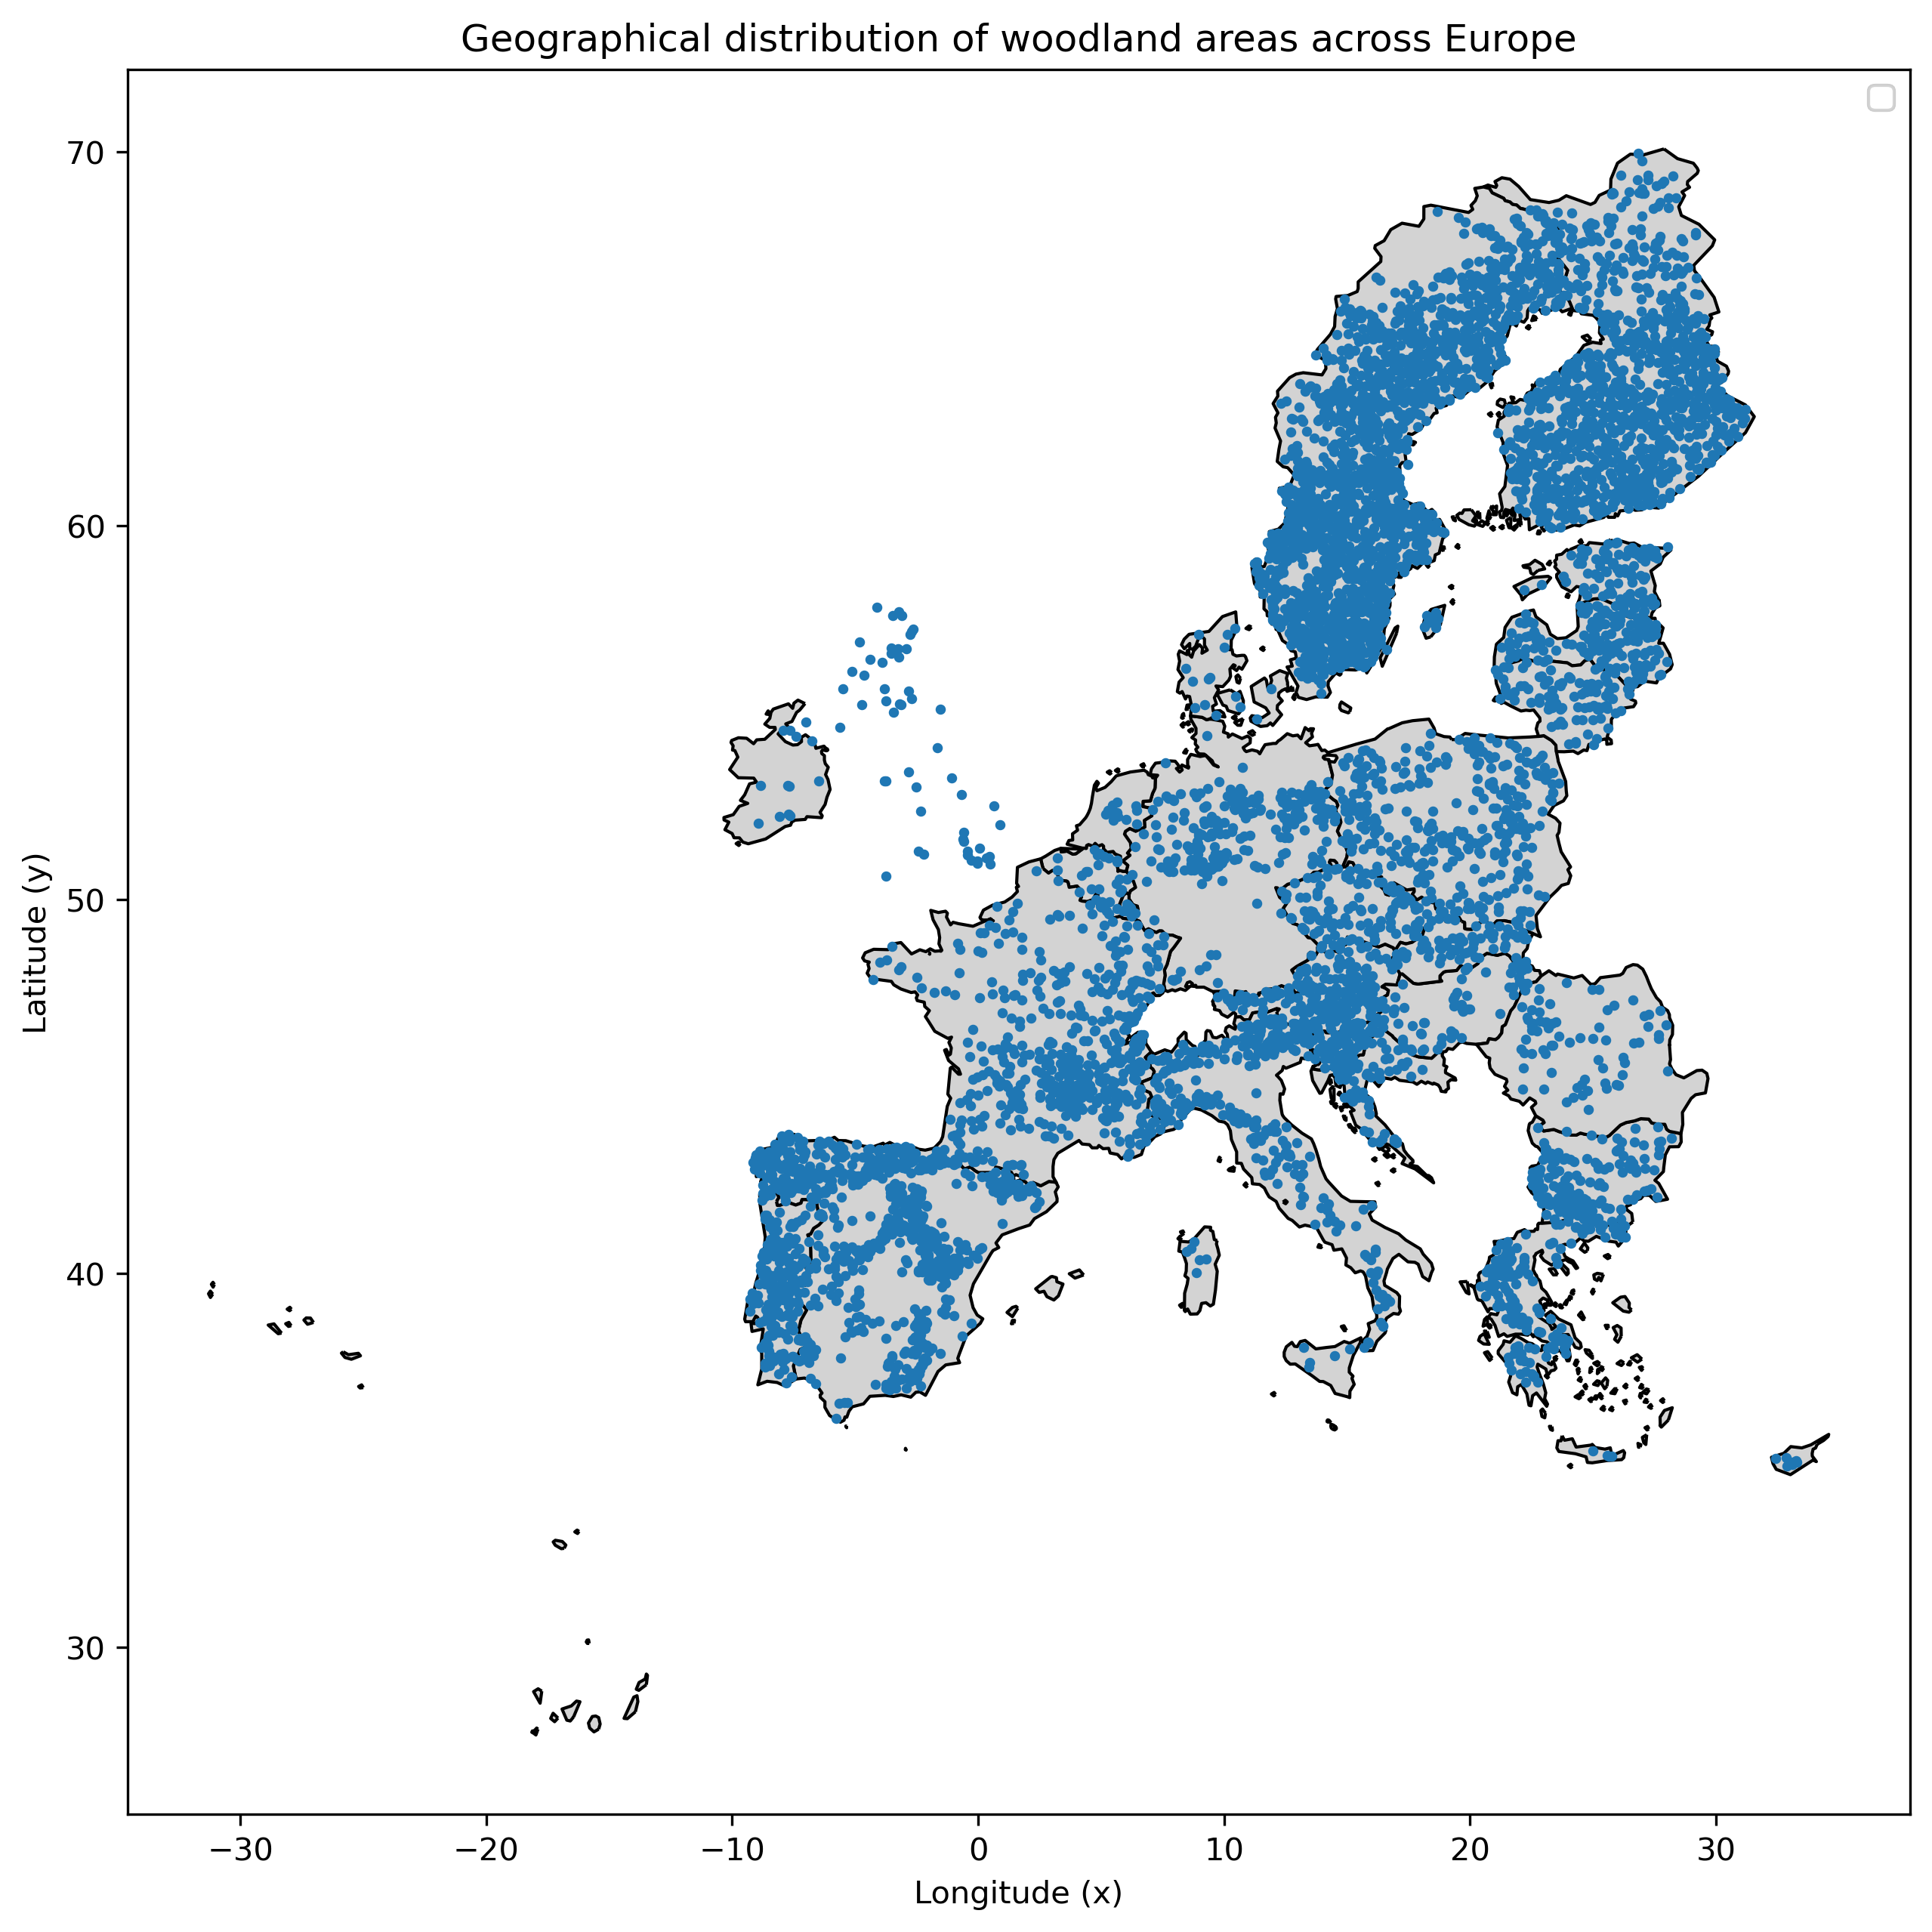

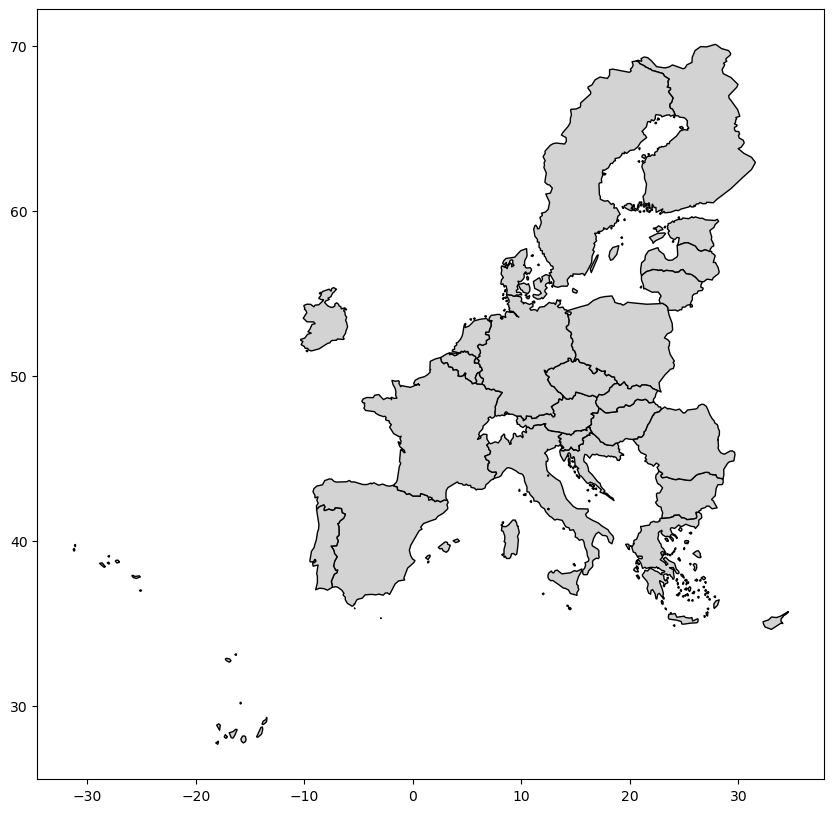

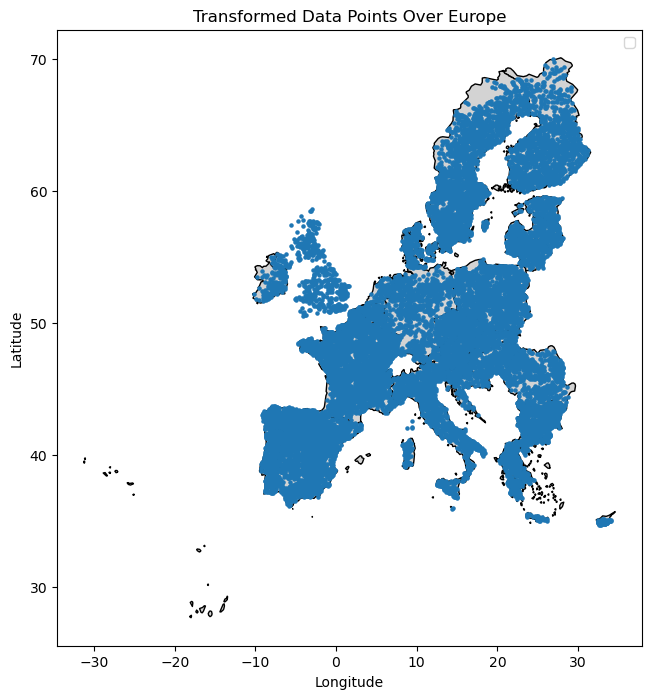

2025-01-21 22:25:34,446 - Using default tokenizer.
2025-01-21 22:25:34,469 - Running initial query
2025-01-21 22:25:39,314 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the 'data_gdf' GeoDataFrame by creating a new column named 'pH_weighted' that is equal to 'pH_CaCl2'. This will be used for weighting points in the heatmap. The resulting transformed data will be stored in 'transformed_gdf'",
  "visualize": "Create a heatmap of Europe where each point on the map is weighted by its corresponding value in the newly created 'pH_weighted' column, using geopandas. Save the result as an image named 'heatmap.png'"
}
```
2025-01-21 22:25:39,314 - Started parsing response
2025-01-21 22:25:39,315 - Parsing successful
2025-01-21 22:25:39,315 - Running transform query
2025-01-21 22:25:47,675 - Transform query finished successfully, response: 
import pandas as pd

transformed_data = data_gdf.copy()  # Create a copy of the original data to avoid modifying it di

Error: Error while running visualize query: name 'pd' is not defined


2025-01-21 22:26:07,641 - Initial query finished successfully, response: 
```
{
  "transform": """
  The 'transform' part of the objective involves creating a new GeoDataFrame where each point is weighted by 'pH_CaCl2'. This can be achieved by selecting only the relevant columns from the original data, including 'geometry', and then multiplying the value in column 'pH_CaCl2' with itself to apply weighting. However, since this is not necessary for a heatmap of pH levels across Europe, we will instead keep the values as they are.
  """,
  
  "visualize": """
  The 'visualize' part of the objective requires creating a weighted point heatmap using geopandas where each point's weight corresponds to its value in column 'pH_CaCl2'. This involves setting up an extent for Europe, then plotting the points on it with their weights. Finally, save this visualization as a .png image file.
  """
}
```
2025-01-21 22:26:07,642 - Started parsing response
2025-01-21 22:26:07,656 - Running initial query


Error: Parsed response is not in json format or does not contain transform, visualize, or column_definitions keys.


2025-01-21 22:26:12,550 - Initial query finished successfully, response: 
{
"transform": "Transform the LUCAS-SOIL-2018 dataset by creating a new GeoDataFrame 'transformed_gdf' where each point is weighted by 'pH_CaCl2'. This involves applying a weight function to the original data, using the 'pH_CaCl_2' column as the value for each feature. The resulting transformed data will contain all columns from the original GeoDataFrame.",
"visualize": "Visualize the transformed data on a heatmap where each point is weighted by 'pH_CaCl2', with Europe's shapefile overlaid in the background. Save the result as a .png file."
}
2025-01-21 22:26:12,551 - Started parsing response
2025-01-21 22:26:12,566 - Running initial query


...

2025-01-21 22:32:32,515 - Initial query finished successfully, response: 
```json
{
  "transform": "First, filter the data to only include rows where 'LC' equals either 'Grassland' or 'Cropland'. Then, perform a t-test on the 'K' column for each class of land use. This will be done by using pandas' built-in functions and comparing means between groups.",
  "visualize": "Next, create box plots to visualize the distribution of K values in Grasslands and Croplands, as well as scatterplots where points are colored based on their respective classes (Grassland or Cropland) for better comparison. This will be done by plotting 'K' against another column such as 'OC'. Lastly, overlay these results onto a map of Europe to illustrate geographical distribution."
}
```
2025-01-21 22:32:32,515 - Started parsing response
2025-01-21 22:32:32,516 - Parsing successful
2025-01-21 22:32:32,516 - Running transform query
2025-01-21 22:32:46,040 - Transform query finished successfully, response: 
# Filter th

Error: Error while running transform query: name 'ttest_ind' is not defined


2025-01-21 22:32:51,549 - Initial query finished successfully, response: 
{
"transform": "The 'pH_H2O' column values are subtracted from the 'K' column values to prepare data for linear regression analysis. This transformation is performed on a copy of the original GeoDataFrame, resulting in a new GeoDataFrame called 'transformed_gdf'.",
"visualize": "A scatter plot and linear regression line are created using seaborn library with Matplotlib backend to visualize the relationship between 'pH_H2O' and 'K' columns from 'transformed_gdf', overlaying this data on a map of Europe, specifically plotting points for each observation in their respective locations based on geographical information."
}
2025-01-21 22:32:51,549 - Started parsing response
2025-01-21 22:32:51,565 - Running initial query


Error: Parsed response is not in json format or does not contain transform, visualize, or column_definitions keys.


2025-01-21 22:32:56,663 - Initial query finished successfully, response: 
```json
{
  "transform": "To transform the data, we will select only two columns ('pH_H2O' and 'K') from the original GeoDataFrame 'data_gdf', then create a scatter plot of K against pH_H2O. Next, perform a linear regression analysis on these two variables to see their relationship.",
  "visualize": "To visualize the data, we will use matplotlib to overlay the scatter plot and regression line created in the transformation step onto a map of Europe, highlighting any patterns or relationships between 'pH_H2O' and 'K'. We may also print some statistical metrics from the linear regression for further insight into their relationship."
}
```
2025-01-21 22:32:56,664 - Started parsing response
2025-01-21 22:32:56,664 - Parsing successful
2025-01-21 22:32:56,664 - Running transform query
2025-01-21 22:33:06,451 - Transform query finished successfully, response: 
transformed_data = data_gdf[['pH_H2O', 'K']].copy()
2025-01-

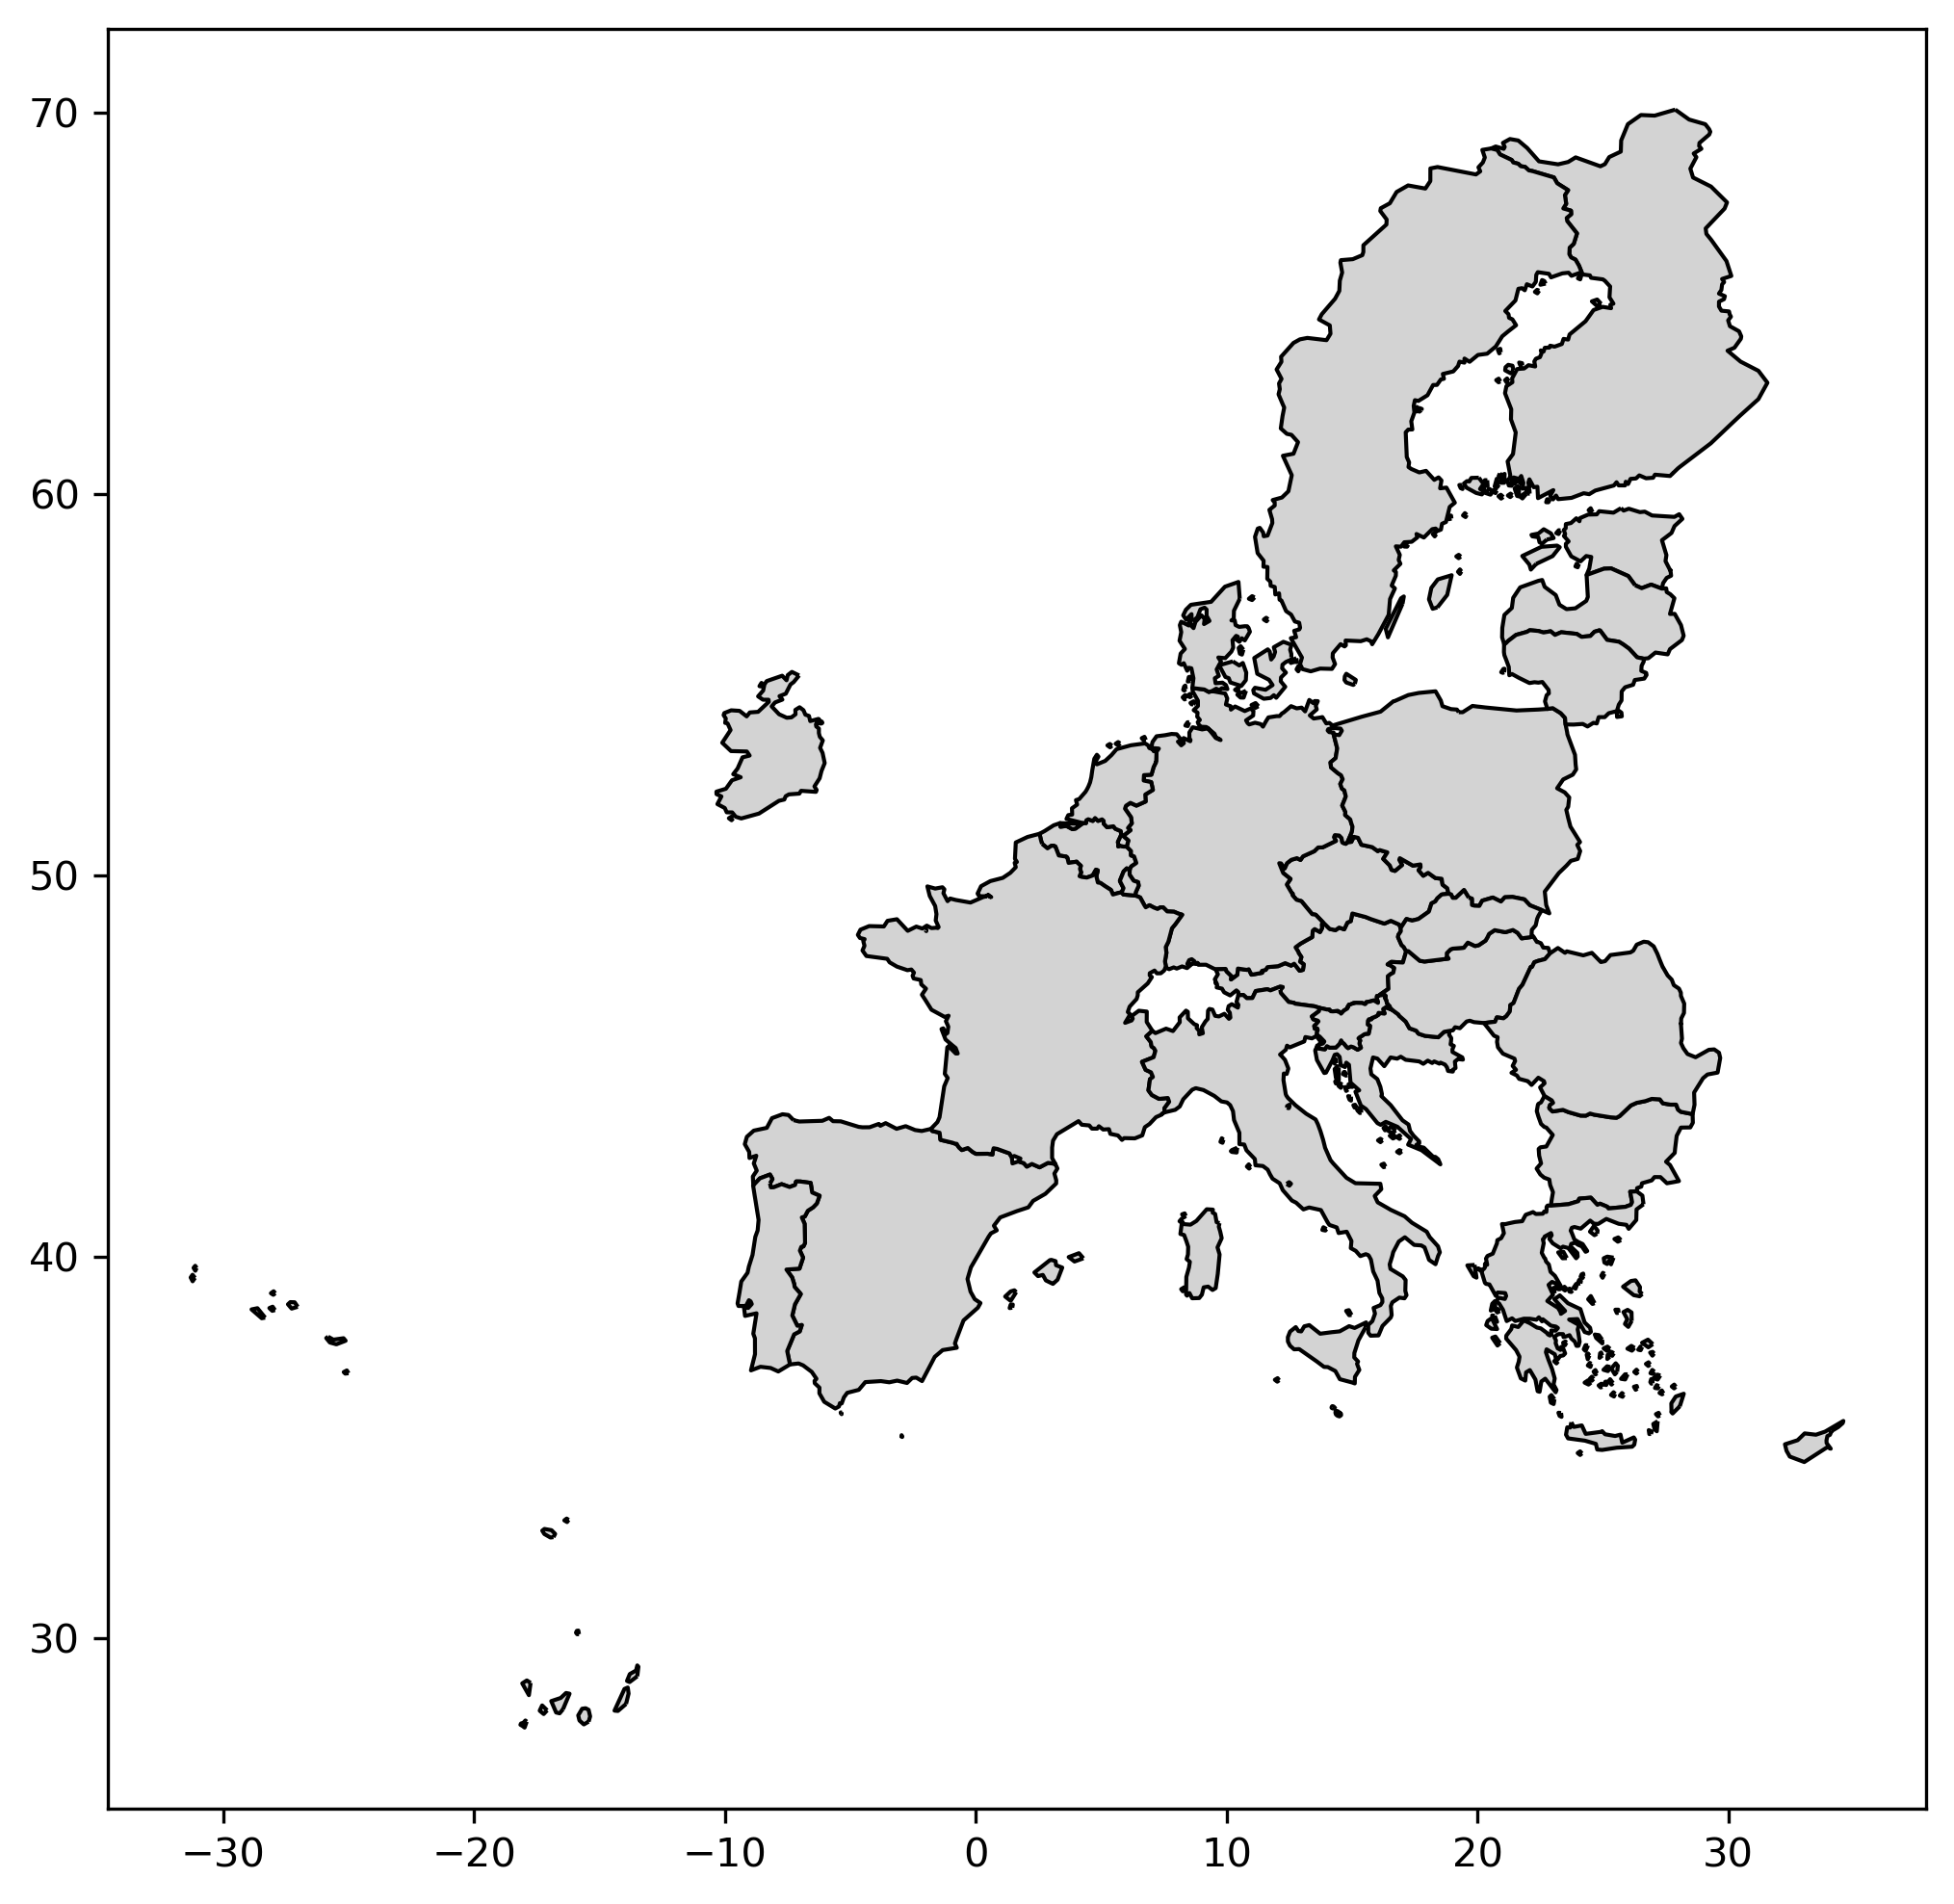

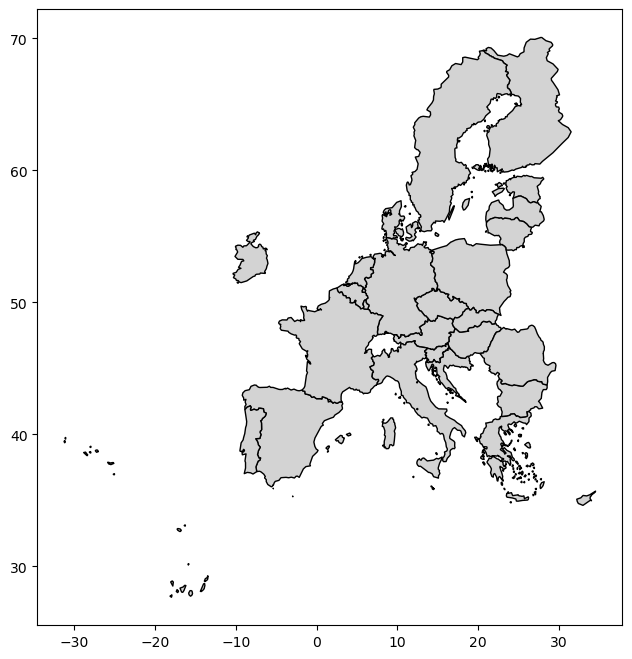

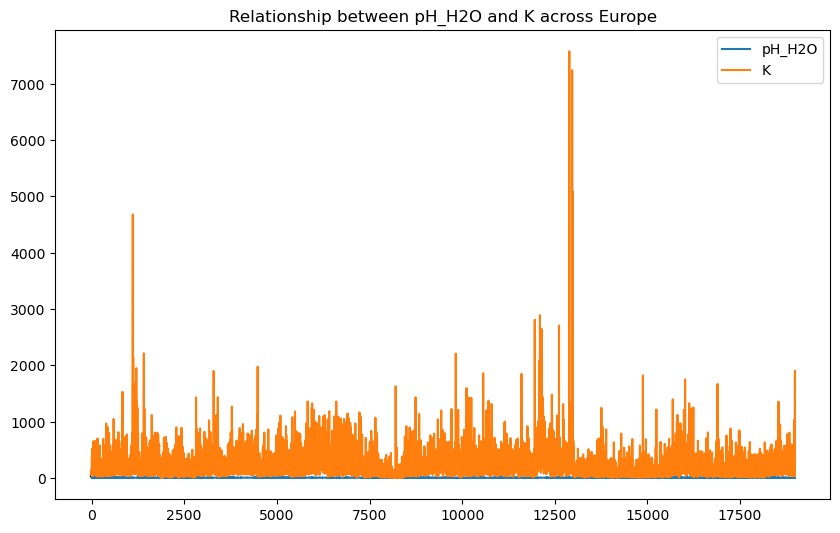

2025-01-21 22:33:16,471 - Using default tokenizer.
2025-01-21 22:33:16,523 - Running initial query
2025-01-21 22:33:21,405 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the 'data_gdf' GeoDataFrame by filtering for rows where OC is not null and then calculate a new column named 'mean_OC' which will contain the mean of all non-null values in the original 'OC' column. The result is stored in a new GeoDataFrame called 'transformed_gdf'.",
  "visualize": "Visualize the distribution of the mean 'OC' content by plotting its histogram from the transformed data and overlaying this information on an interactive map of Europe with color representing different confidence intervals for each region."
}
```
2025-01-21 22:33:21,405 - Started parsing response
2025-01-21 22:33:21,407 - Parsing successful
2025-01-21 22:33:21,407 - Running transform query
2025-01-21 22:33:31,643 - Transform query finished successfully, response: 
transformed_data = data_gdf.loc[data

Error: Error while running visualize query: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).


2025-01-21 22:33:51,598 - Initial query finished successfully, response: 
```json
{
  "transform": "First, filter the 'data_gdf' GeoDataFrame to only include rows where the value of the 'OC' column is not null. Next, calculate a 95% confidence interval for the mean OC content in the dataset using the filtered data and store it in a new 'mean_OC_ci' column.",
  "visualize": "Plot the map of Europe with points representing the locations from which soil samples were collected, where each point's color varies based on its corresponding value in the 'OC' column. Overlay histograms or box plots for the OC content values at the bottom-right corner to visualize the distribution and check if it aligns with the calculated confidence interval."
}
```
2025-01-21 22:33:51,598 - Started parsing response
2025-01-21 22:33:51,599 - Parsing successful
2025-01-21 22:33:51,599 - Running transform query
2025-01-21 22:34:05,960 - Transform query finished successfully, response: 
import pandas as pd

# Filte

Error: Error while running transform query: f-string: unmatched ')' (<string>, line 6)


2025-01-21 22:34:12,530 - Initial query finished successfully, response: 
```json
{
  "transform": {
    "Calculate the mean and standard deviation of 'OC' content in the dataset by applying pandas.DataFrame.agg() method to select the required statistics on the filtered column, which excludes NaN values. This will be stored as a new GeoDataFrame called 'transformed_gdf'.",
    "Compute a 95% confidence interval for the calculated mean using scipy.stats.norm.interval(). The parameters of this function include mu (the population mean) and sigma (population standard deviation), both obtained from the previous step."
  },
  "visualize": {
    "Use matplotlib to plot a histogram representing the distribution of 'OC' values. This will help in understanding how well our sample represents the actual population.",
    "Overlay this histogram on an interactive map of Europe, with each point color-coded based on its OC value range (e.g., <1%, 1-2%, ..., >5%) using plotly library and Cartopy for c

...

Error: Error while running transform query: name 'pd' is not defined


2025-01-21 22:36:33,369 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the 'K' content in the entire dataset by converting it into a pandas Series, and then calculate its mean. Next, perform a t-test to check if this calculated mean is significantly different from 2% using the hypothesis test. Store the results in a new GeoDataFrame called 't_result'.",
  "visualize": "Visualize the result of the t-test by printing out whether it was rejected or not and show the p-value, then overlay this information on an interactive map of Europe to make it easier for users to understand the significance and location where the mean K content differs from 2%."
}
```
2025-01-21 22:36:33,370 - Started parsing response
2025-01-21 22:36:33,372 - Parsing successful
2025-01-21 22:36:33,373 - Running transform query
2025-01-21 22:36:44,543 - Transform query finished successfully, response: 
# Transform the 'K' content in the entire dataset by converting it into a pandas

Error: Error while running transform query: name 'pd' is not defined


2025-01-21 22:36:50,241 - Initial query finished successfully, response: 
```json
{
  "transform": "Transform the 'data_gdf' GeoDataFrame by performing a t-test to determine if the mean 'K' content in the entire dataset is significantly different from 2%, which will be stored as 't_test_result'. The transformed data will contain all columns of the original GeoDataFrame, plus an additional column with the result of the hypothesis test.",
  
  "visualize": "Visualize the results of the t-test by creating a histogram to show the distribution of 'K' content values. Overlay this information on top of the map of Europe, highlighting countries where the null hypothesis cannot be rejected (i.e., mean K content is not significantly different from 2%), and highlight those that do reject it (countries with significant difference)."
}
```
2025-01-21 22:36:50,242 - Started parsing response
2025-01-21 22:36:50,243 - Parsing successful
2025-01-21 22:36:50,243 - Running transform query
2025-01-21 22:3

Error: Error while running visualize query: too many values to unpack (expected 2)


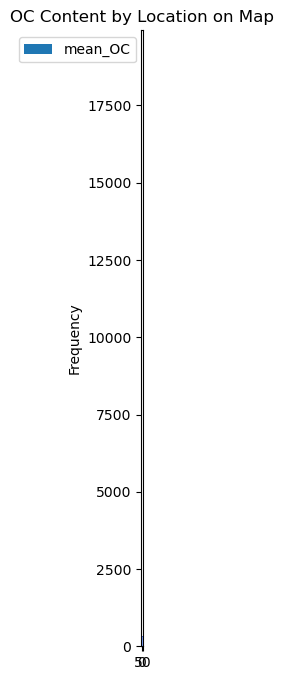

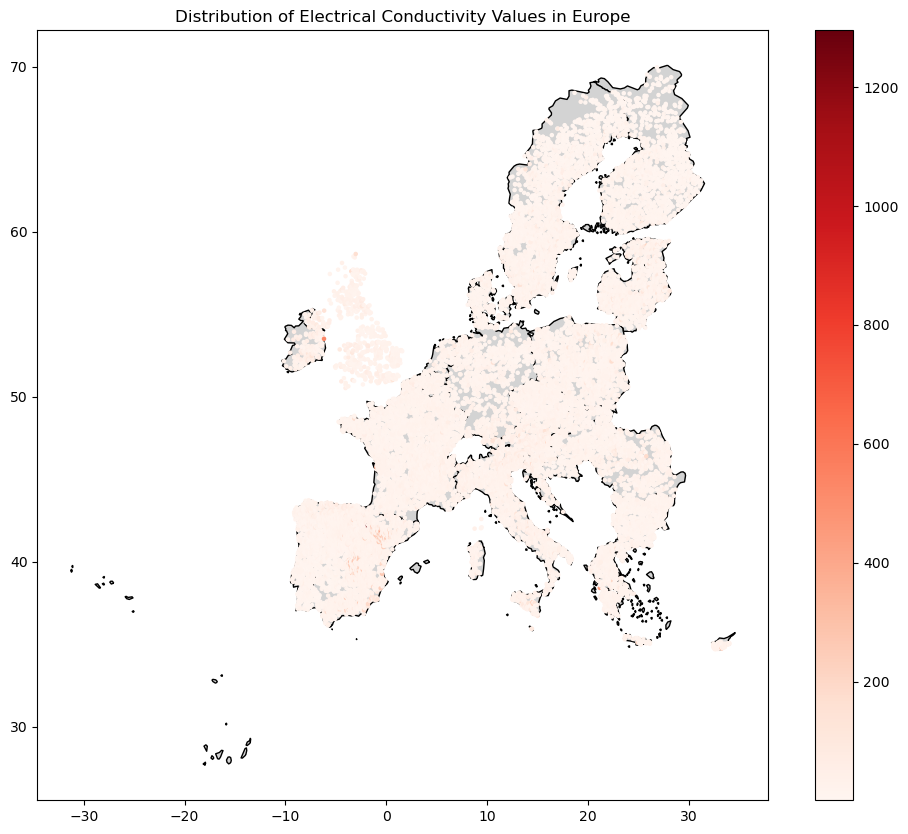

<Figure size 1000x700 with 0 Axes>

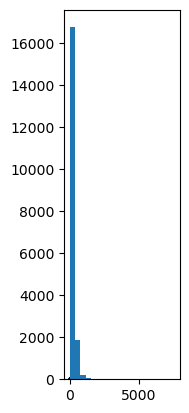

In [12]:
for query_type in query_types:
    query_count = len(os.listdir(BASE_QUERY_DIR + query_type))
    print(f"Processing {query_count} {query_type} queries")
    os.makedirs(f"{BASE_GENERATED_DIR}{query_type}", exist_ok=True)
    os.makedirs(f"{BASE_METRICS_DIR}{model_id}/{query_type}", exist_ok=True)
    
    for file in os.listdir(BASE_QUERY_DIR + query_type):
        query_index = int(file.split('.')[0])
        
        query = open(f"{BASE_QUERY_DIR}{query_type}/{file}", 'r').read()
        correct_result = open(f"{BASE_CORRECT_RESULT_DIR}{query_type}/{file}", 'r').read()
        
        generated_result = None
        for i in range(3):
            try:
                generated_result = solution_code_string = run_pipeline(
                    objective=query,
                    client_instructor=client_instructor,
                    client_coder=client_coder,
                    data_gdf=data_gdf,
                    europe_gdf=europe_gdf,
                    transform_functions=transform_functions,
                    visualize_functions=visualize_functions,
                )
                break
            except Exception as e:
                print(f"Error: {e}")
        
        if not generated_result is None:
            open(f"{BASE_GENERATED_DIR}{query_type}/{query_index}.txt", 'w').write(generated_result)
            
            metrics = evaluate_metrics(correct_result, generated_result)
            metrics.MODEL_ID = model_id
            with open(f"{BASE_METRICS_DIR}{model_id}/{query_type}/{query_index}.json", 'w') as f:
                json.dump(metrics.model_dump(), f, indent=4)

2025-01-21 21:36:00,839 - Running initial query
2025-01-21 21:36:05,235 - Initial query finished successfully, response: 
```json
{
  "transform": "Filter the data to include only rows where pH_CaCl2 > 6, resulting in 'transformed_gdf' GeoDataFrame.",
  "visualize": "Plot all points from 'transformed_gdf' on a map using geopandas. Save the image as a png file."
}
```
2025-01-21 21:36:05,236 - Started parsing response
2025-01-21 21:36:05,236 - Parsing successful
2025-01-21 21:36:05,237 - Running transform query
2025-01-21 21:36:16,646 - Running visualize query
2025-01-21 21:36:30,448 - Visualize query finished successfully, response: 
import matplotlib.pyplot as plt

# Set up the plot with europe_gdf as base map
ax = transformed_data.plot(figsize=(10, 8))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Plot points from 'transformed_data' on a map using geopandas
transformed_data.plot(ax=ax, markersize=5)

# Set labels and title for the plot
ax.set_title('LUCAS-SOIL-2018 

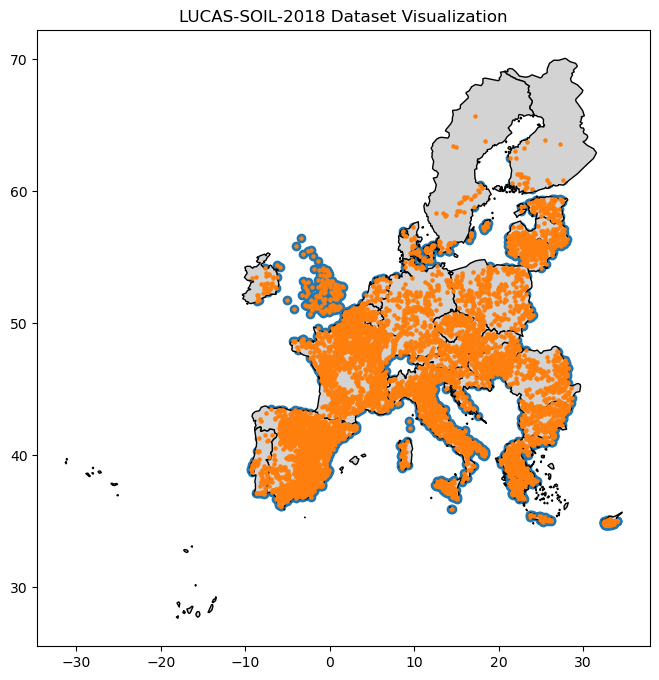

In [186]:
solution_code_string = run_pipeline(
    objective=objective,
    client_instructor=client_instructor,
    client_coder=client_coder,
    data_gdf=data_gdf,
    europe_gdf=europe_gdf,
    transform_functions=transform_functions,
    visualize_functions=visualize_functions,
)